<a href="https://www.kaggle.com/code/ramrajadataanalyst/customer-analysis?scriptVersionId=303792111" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# Customer Analytics — End-to-End
**Author:** Ramraja Yadav — Delhi NCR, India  
Email: ramraja.analyst@gmail.com · LinkedIn: linkedin.com/in/ramraja · GitHub: github.com/imramraja

I cleaned and prepared transaction data, answered business questions with clear plots and short insights, build RFM & cohorts, and created ML baselines. 


## 1 Libraries

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize']=(12,5)

In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, mean_squared_error

## 2 Load data

In [4]:
file_path = '/kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv'  

df = pd.read_csv(file_path)
df.columns = [c.replace(' ','_') for c in df.columns]
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Quick data check

In [5]:
df.shape

(1067371, 8)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer_ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Invoice,1067371,53628,537434,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,1067371,5305,85123A,5829,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,1062989,5698,WHITE HANGING HEART T-LIGHT HOLDER,5918,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1067371.0,NaN,NaN,NaN,9.938898,172.705794,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,1067371,47635,2010-12-06 16:57:00,1350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Price,1067371.0,NaN,NaN,NaN,4.649388,123.553059,-53594.36,1.25,2.1,4.15,38970.0
Customer_ID,824364.0,NaN,NaN,NaN,15324.638504,1697.46445,12346.0,13975.0,15255.0,16797.0,18287.0
Country,1067371,43,United Kingdom,981330,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3 Data cleaning — stepwise (small cells with short notes)

### 3.1 Remove rows without Customer_ID

In [8]:
df = df.dropna(subset=['Customer_ID'])
df['Customer_ID'] = df['Customer_ID'].astype(str)
df.shape

(824364, 8)

### 3.2 Remove exact duplicates

In [9]:
df = df.drop_duplicates()
df.shape

(797885, 8)

### 3.3 Invoice cancellations

In [10]:
df['Invoice'] = df['Invoice'].astype(str)
df['IsCancellation'] = df['Invoice'].str.startswith('C')
print(df['IsCancellation'].value_counts())
# keep only non-cancellations
df = df[~df['IsCancellation']].copy()
df.shape

IsCancellation
False    779495
True      18390
Name: count, dtype: int64


(779495, 9)

### 3.4 Quantity & Price validity

In [11]:
print('Before:', df.shape)
df = df[df['Quantity']>0]
df = df[df['Price']>0]
print('After:', df.shape)

Before: (779495, 9)
After: (779425, 9)


### 3.5 Description and date parsing

In [12]:
df = df.dropna(subset=['Description'])
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df = df.dropna(subset=['InvoiceDate'])
print(df['InvoiceDate'].min(), df['InvoiceDate'].max())

2009-12-01 07:45:00 2011-12-09 12:50:00


### 3.6 Outlier inspection and safe capping (IQR 1–99%)

In [13]:
df[['Quantity','Price']].quantile([0.01,0.05,0.5,0.95,0.99])

,Quantity,Price
0.01,1.0,0.29
0.05,1.0,0.42
0.50,6.0,1.95
0.95,36.0,8.50
0.99,144.0,14.95


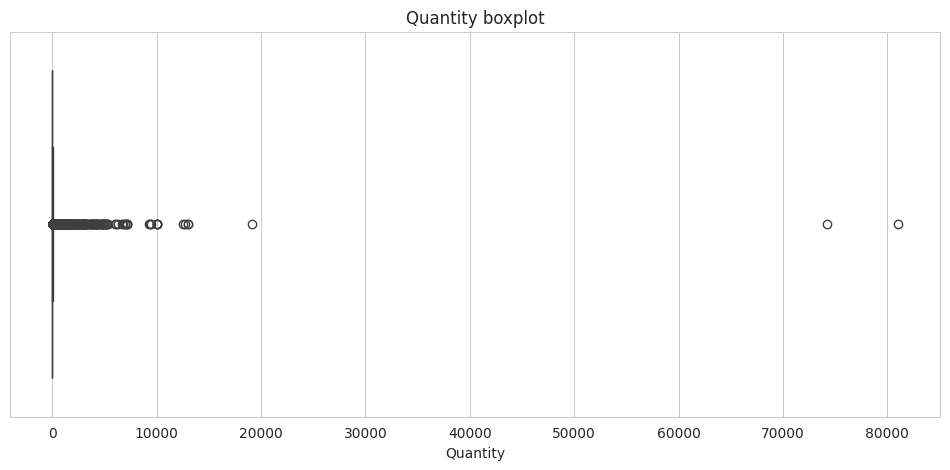

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df['Quantity']); plt.title('Quantity boxplot'); plt.show()

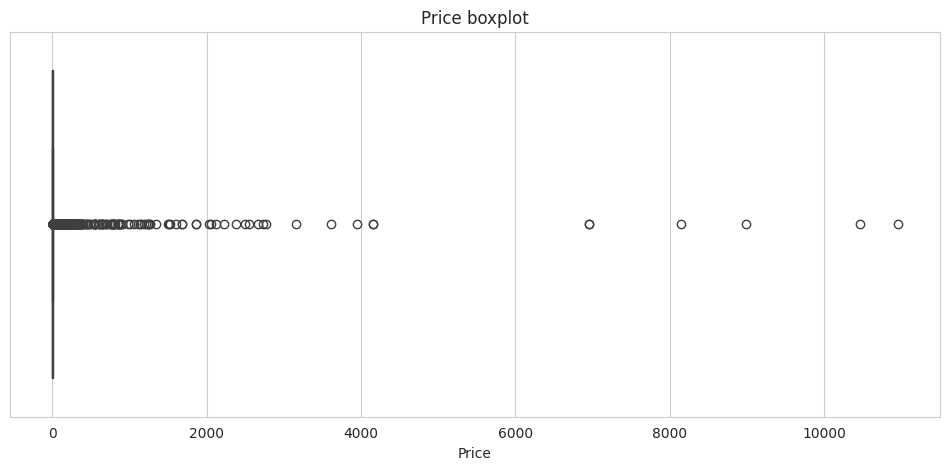

In [15]:
sns.boxplot(x=df['Price']); plt.title('Price boxplot'); plt.show()

I cap extreme Quantity/Price at 99th percentile to avoid erroneous spikes impacting aggregates.

In [16]:
q99_q = df['Quantity'].quantile(0.99)
q99_p = df['Price'].quantile(0.99)
df['Quantity_capped'] = np.where(df['Quantity']>q99_q, q99_q, df['Quantity'])
df['Price_capped'] = np.where(df['Price']>q99_p, q99_p, df['Price'])
df['Revenue'] = df['Quantity_capped'] * df['Price_capped']
df[['Quantity_capped','Price_capped','Revenue']].describe(percentiles=[0.01,0.05,0.5,0.95,0.99])

,Quantity_capped,Price_capped,Revenue
count,779425.000000,779425.000000,779425.000000
mean,11.172854,2.887385,19.724500
std,19.793596,2.802798,39.485518
min,1.000000,0.001000,0.001000
1%,1.000000,0.290000,0.600000
5%,1.000000,0.420000,1.250000
50%,6.000000,1.950000,12.480000
95%,36.000000,8.500000,63.500000
99%,144.000000,14.950000,179.000000
max,144.000000,14.950000,2152.800000


## 4 Transaction-level features

In [17]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['InvoiceWeek'] = df['InvoiceDate'].dt.to_period('W')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df[['InvoiceDate','InvoiceMonth','DayOfWeek','Year','Month','Hour']].head()

,InvoiceDate,InvoiceMonth,DayOfWeek,Year,Month,Hour
0,2009-12-01 07:45:00,2009-12,Tuesday,2009,12,7
1,2009-12-01 07:45:00,2009-12,Tuesday,2009,12,7
2,2009-12-01 07:45:00,2009-12,Tuesday,2009,12,7
3,2009-12-01 07:45:00,2009-12,Tuesday,2009,12,7
4,2009-12-01 07:45:00,2009-12,Tuesday,2009,12,7


## 5 Product & country aggregates

In [18]:
top_products = df.groupby('Description')[['Quantity_capped','Revenue']].sum().sort_values('Revenue',ascending=False).head(15)
top_products

,Quantity_capped,Revenue
Description,,
REGENCY CAKESTAND 3 TIER,23384.0,269403.10
WHITE HANGING HEART T-LIGHT HOLDER,75895.0,205034.67
JUMBO BAG RED RETROSPOT,62654.0,114476.82
PARTY BUNTING,23320.0,102709.58
ASSORTED COLOUR BIRD ORNAMENT,63341.0,102459.41
POSTAGE,5235.0,77680.02
PAPER CHAIN KIT 50'S CHRISTMAS,24358.0,66510.38
CHILLI LIGHTS,13395.0,62865.58
JUMBO BAG STRAWBERRY,30590.0,55254.21


In [19]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(15)
top_countries

Country
United Kingdom     1.278307e+07
EIRE               5.349906e+05
Netherlands        4.621123e+05
Germany            4.095626e+05
France             3.126164e+05
Australia          1.464701e+05
Switzerland        9.524569e+04
Spain              8.953899e+04
Sweden             7.090292e+04
Belgium            6.276620e+04
Portugal           4.920997e+04
Channel Islands    4.189137e+04
Norway             3.912881e+04
Denmark            3.533892e+04
Japan              3.123335e+04
Name: Revenue, dtype: float64

## 6 EDA — revenue trends and short insights

In [20]:
monthly_revenue = df.resample('ME', on='InvoiceDate')['Revenue'].sum()
monthly_revenue_rolling = monthly_revenue.rolling(3).mean()

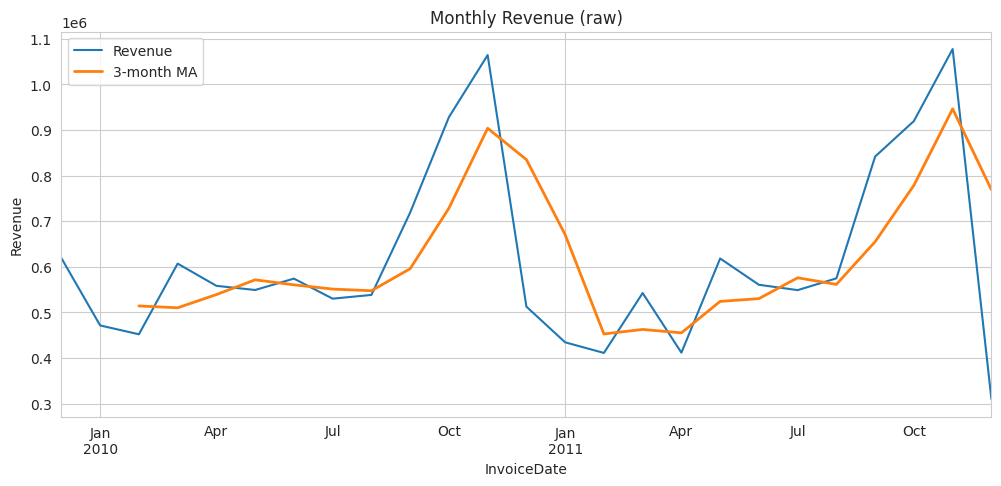

In [21]:
ax = monthly_revenue.plot(title='Monthly Revenue (raw)')
monthly_revenue_rolling.plot(ax=ax, linewidth=2, label='3-month MA')
ax.set_ylabel('Revenue')
plt.legend(); plt.show()

**Insight:** Check peaks and troughs — these indicate seasonality or one-off campaigns. Note concentration from Pareto section.

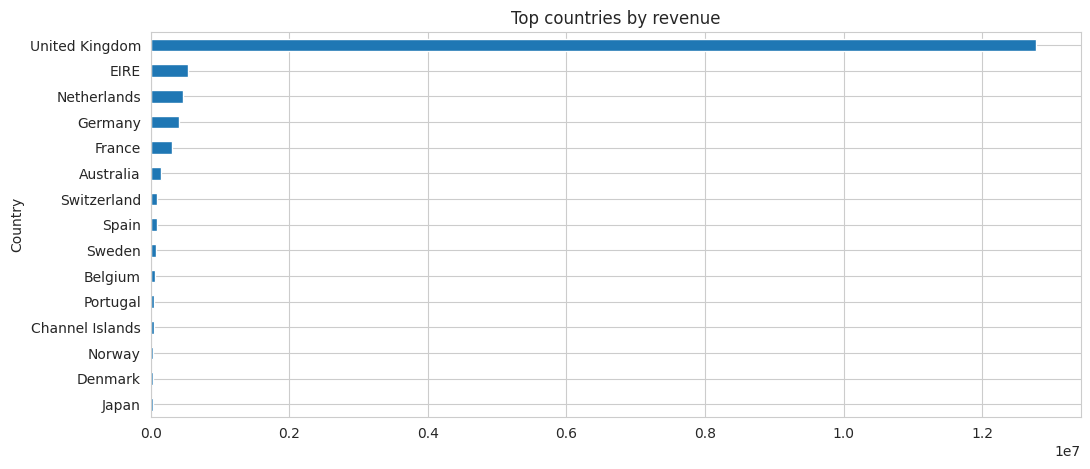

In [22]:
ax = top_countries.plot(kind='barh')
ax.set_title('Top countries by revenue')
plt.gca().invert_yaxis(); plt.show()

**Insight:** Country with highest revenue should be prioritized for marketing and stock planning.

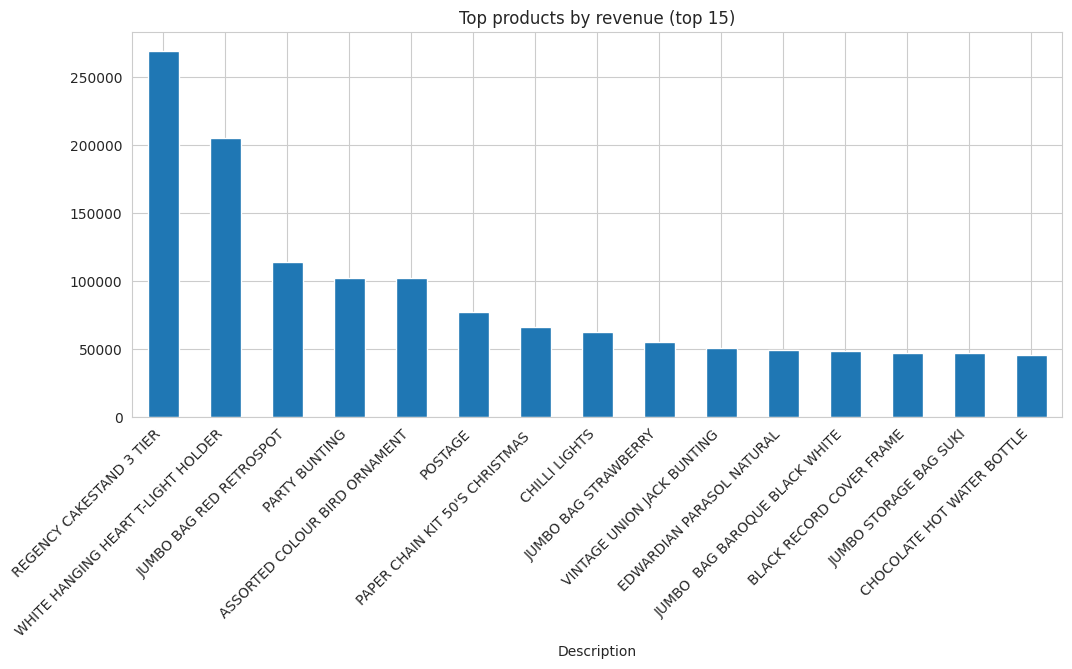

In [23]:
ax = top_products['Revenue'].plot(kind='bar')
ax.set_title('Top products by revenue (top 15)')
plt.xticks(rotation=45, ha='right'); plt.show()

**Insight:** Top products drive a large share of revenue; consider bundles or supplier focus.

## 7 Basket / invoice-level analysis

In [24]:
invoice_value = df.groupby('Invoice')['Revenue'].sum()
invoice_value.describe(percentiles=[0.01,0.05,0.5,0.95,0.99])

count    36969.000000
mean       415.855671
std        666.727578
min          0.380000
1%           8.500000
5%          29.900000
50%        295.450000
95%       1130.992000
99%       2738.906800
max      29043.760000
Name: Revenue, dtype: float64

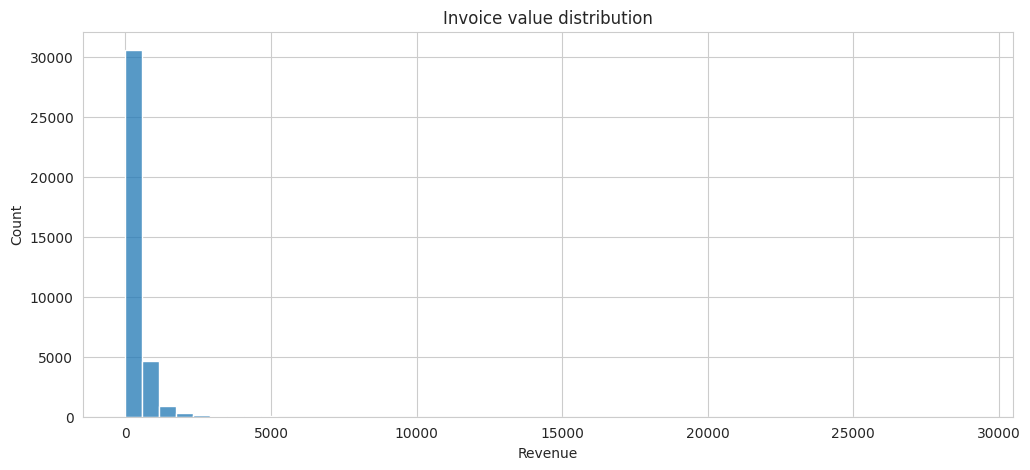

In [25]:
sns.histplot(invoice_value, bins=50)
plt.title('Invoice value distribution'); plt.show()

**Insight:** Most invoices are small; a few large invoices drive revenue — use different tactics for these groups.

### Outlier handling: IQR cap (1–99%) and winsorize — create Revenue_clean and Revenue_log1p

In [26]:
def iqr_cap(s, lower_q=0.01, upper_q=0.99):
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi)

# create cleaned revenue columns
if 'Revenue' in df.columns:
    df['Revenue_iqr'] = iqr_cap(df['Revenue'])
    from scipy.stats.mstats import winsorize
    df['Revenue_winsor'] = np.array(winsorize(df['Revenue'], limits=[0.01,0.01]))
    df['Revenue_clean'] = df['Revenue_iqr']
    df['Revenue_log1p'] = np.log1p(df['Revenue_clean'])
    print('Created Revenue_clean and Revenue_log1p')
else:
    print('Revenue not found')

Created Revenue_clean and Revenue_log1p


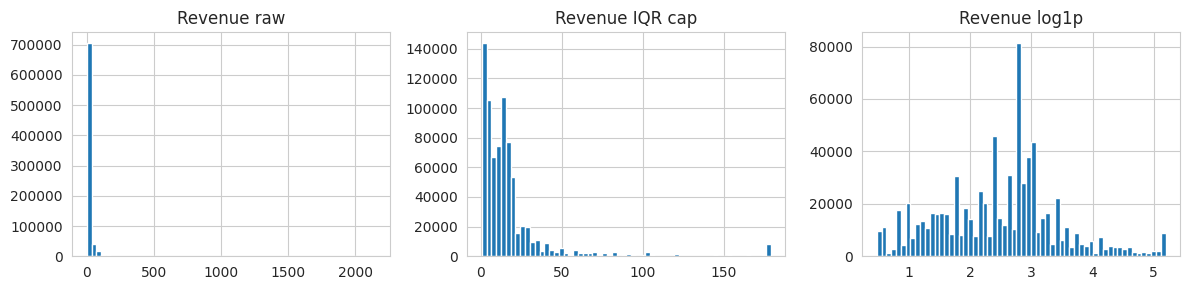

In [27]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); plt.hist(df['Revenue'], bins=60); plt.title('Revenue raw')
plt.subplot(1,3,2); plt.hist(df['Revenue_iqr'], bins=60); plt.title('Revenue IQR cap')
plt.subplot(1,3,3); plt.hist(df['Revenue_log1p'], bins=60); plt.title('Revenue log1p')
plt.tight_layout(); plt.show()

**Insight:** Use `Revenue_clean` for business totals and `Revenue_log1p` for ML features; both are kept for transparency.

## 8 Pareto & concentration metrics

In [28]:
customer_revenue = df.groupby('Customer_ID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head(10)

Customer_ID
14646.0    437601.49
18102.0    359316.92
14911.0    270592.13
14156.0    253106.26
13694.0    167164.63
17511.0    166774.99
12415.0    123230.03
15311.0    113073.02
13089.0    112361.51
16684.0    111061.11
Name: Revenue, dtype: float64

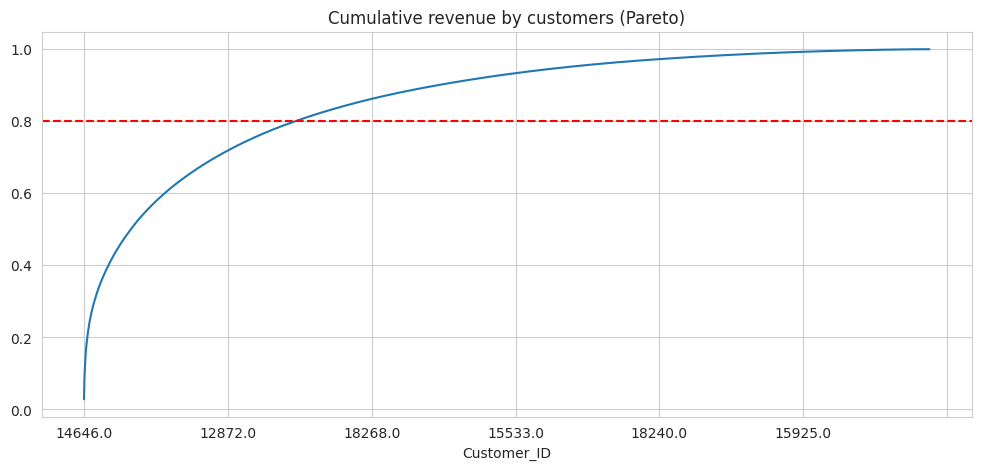

In [29]:
cum_rev = customer_revenue.cumsum() / customer_revenue.sum()
ax = cum_rev.plot()
ax.axhline(0.8, color='red', linestyle='--')
ax.set_title('Cumulative revenue by customers (Pareto)')
plt.show()

In [30]:
# concentration metrics
n = len(customer_revenue)
top1 = max(1, int(n*0.01))
share_top1 = customer_revenue.head(top1).sum() / customer_revenue.sum()
share_top10 = customer_revenue.head(10).sum() / customer_revenue.sum()
print(f'Top {top1} customers (1%) share: {share_top1:.2%}')
print(f'Top 10 customers share: {share_top10:.2%}')
# approximate Gini
arr = customer_revenue.values
arr_sorted = np.sort(arr)
cum = np.cumsum(arr_sorted)
lorenz = np.concatenate([[0], cum / cum[-1]])
xs = np.linspace(0,1,len(lorenz))
gini = 1 - 2 * np.trapz(lorenz, xs)
print(f'Approx Gini: {gini:.3f}')

Top 58 customers (1%) share: 27.77%
Top 10 customers share: 13.75%
Approx Gini: 0.721


/tmp/ipykernel_17/1409854495.py:14: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  gini = 1 - 2 * np.trapz(lorenz, xs)


**Insight (concentration):** High concentration suggests treating top customers with differentiated retention and forecasting strategies.

## 9 Cohort retention (monthly cohorts)

In [31]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('Customer_ID')['InvoiceDate'] \
                      .transform('min') \
                      .dt.to_period('M')

In [32]:
df['CohortIndex'] = (
    (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 +
    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)
)

In [33]:
cohort_data = df.groupby(['CohortMonth','CohortIndex'])['Customer_ID'] \
                .nunique() \
                .reset_index()

In [34]:
cohort_pivot = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer_ID'
)

In [35]:
cohort_size = cohort_pivot.iloc[:,0]

retention = cohort_pivot.divide(cohort_size, axis=0)

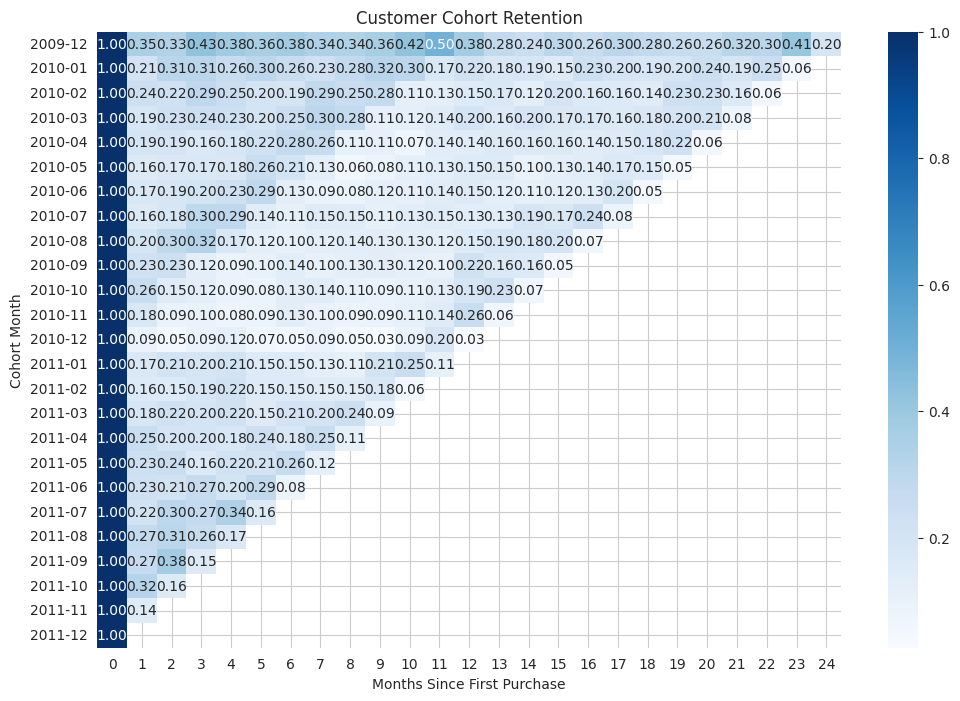

In [36]:
plt.figure(figsize=(12,8))

sns.heatmap(
    retention,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Customer Cohort Retention")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")

plt.show()

**Insight:** Retention typically drops after month 1; focus on onboarding and early engagement to improve retention.

## 10 Customer lifetime features (aggregates)

In [37]:
cust = df.groupby('Customer_ID').agg(
    TotalOrders=('Invoice','nunique'),
    TotalQuantity=('Quantity_capped','sum'),
    TotalRevenue=('Revenue','sum'),
    FirstPurchase=('InvoiceDate','min'),
    LastPurchase=('InvoiceDate','max')
).reset_index()

cust['CustomerLifetimeDays'] = (cust['LastPurchase'] - cust['FirstPurchase']).dt.days
cust['AvgOrderValue'] = cust['TotalRevenue'] / cust['TotalOrders']
cust['OrdersPerMonth'] = cust['TotalOrders'] / ((cust['CustomerLifetimeDays']/30).replace(0,1))
cust.head()

,Customer_ID,TotalOrders,TotalQuantity,TotalRevenue,FirstPurchase,LastPurchase,CustomerLifetimeDays,AvgOrderValue,OrdersPerMonth
0,12346.0,12,214.0,522.62,2009-12-14 08:34:00,2011-01-18 10:01:00,400,43.551667,0.900000
1,12347.0,8,2871.0,4821.69,2010-10-31 14:20:00,2011-12-07 15:52:00,402,602.711250,0.597015
2,12348.0,5,2714.0,1793.95,2010-09-27 14:59:00,2011-09-25 13:13:00,362,358.790000,0.414365
3,12349.0,4,1624.0,3612.54,2010-04-29 13:20:00,2011-11-21 09:51:00,570,903.135000,0.210526
4,12350.0,1,197.0,309.35,2011-02-02 16:01:00,2011-02-02 16:01:00,0,309.350000,1.000000


**Insight:** Lifetime features help profile customers for CLV and churn analysis.

## 11 RFM calculation and scoring (cleaned Monetary)

In [38]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer_ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue_clean' if 'Revenue_clean' in df.columns else 'Revenue', 'sum')
)
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
12346.0,326,12,522.62
12347.0,2,8,4821.69
12348.0,75,5,1793.95
12349.0,19,4,3612.54
12350.0,310,1,309.35


In [39]:
rfm['Monetary_log1p'] = np.log1p(rfm['Monetary'])
rfm['R_score'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),5,labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary_log1p'],5,labels=[1,2,3,4,5])
rfm['RFM_Score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm[['Recency','Frequency','Monetary','Monetary_log1p','R_score','F_score','M_score']].head()

,Recency,Frequency,Monetary,Monetary_log1p,R_score,F_score,M_score
Customer_ID,,,,,,,
12346.0,326,12,522.62,6.260766,2,5,2
12347.0,2,8,4821.69,8.481087,5,4,5
12348.0,75,5,1793.95,7.492732,3,4,4
12349.0,19,4,3612.54,8.192443,5,3,5
12350.0,310,1,309.35,5.737701,2,1,2


**Note:** Monetary is scored on log1p of cleaned revenue to reduce skew influence.

### 11-tier rule-based RFM segments

In [40]:
def rfm_segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    if r>=4 and f>=4 and m>=4:
        return 'Champions'
    if r>=3 and f>=4:
        return 'Loyal Customers'
    if r>=4 and f>=2:
        return 'Potential Loyalists'
    if r==5 and f==1:
        return 'New Customers'
    if r==4 and f==1:
        return 'Promising'
    if r==3 and f==2:
        return 'Need Attention'
    if r==2 and f>=2:
        return 'About To Sleep'
    if r<=2 and f>=4:
        return 'At Risk'
    if r==1 and f>=4:
        return 'Cannot Lose Them'
    if r==2 and f==1:
        return 'Hibernating'
    return 'Lost'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)
rfm['Segment'].value_counts().head(20)

Segment
Lost                   1544
Champions              1297
About To Sleep          869
Potential Loyalists     714
Loyal Customers         701
Hibernating             303
Need Attention          193
Promising               114
At Risk                  89
New Customers            54
Name: count, dtype: int64

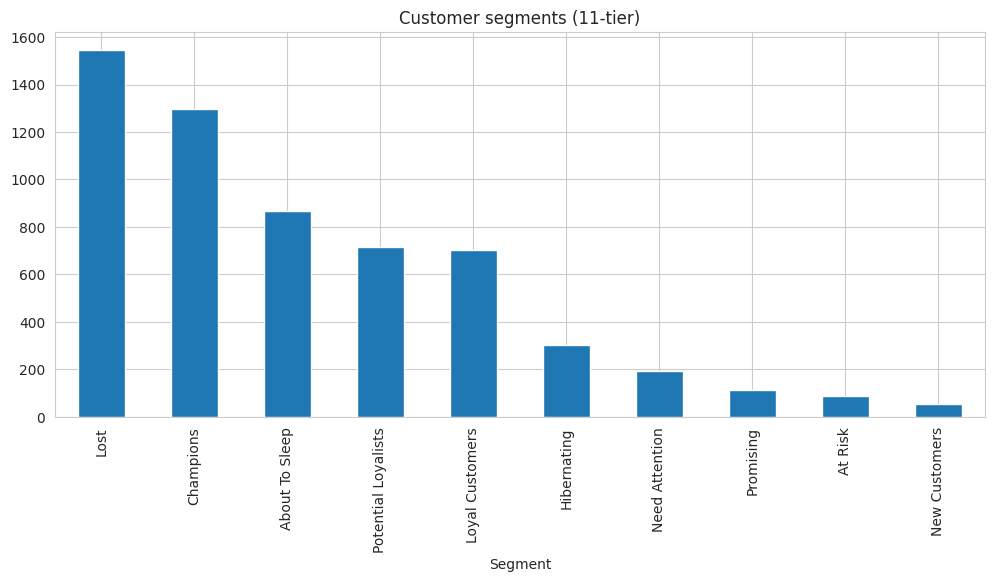

In [41]:
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Customer segments (11-tier)')
plt.show()

**Insight:** Segments help prioritize retention (Champions, Cannot Lose Them) vs reactivation (About To Sleep, Hibernating).

## 12 Clustering (KMeans) on scaled RFM

In [42]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,345.414908,2.631266,788.768529
1,27.570755,41.537736,19100.469387
2,55.022951,6.225931,2147.957091
3,2.800000,201.100000,162201.920000
4,597.840764,1.624204,453.248586


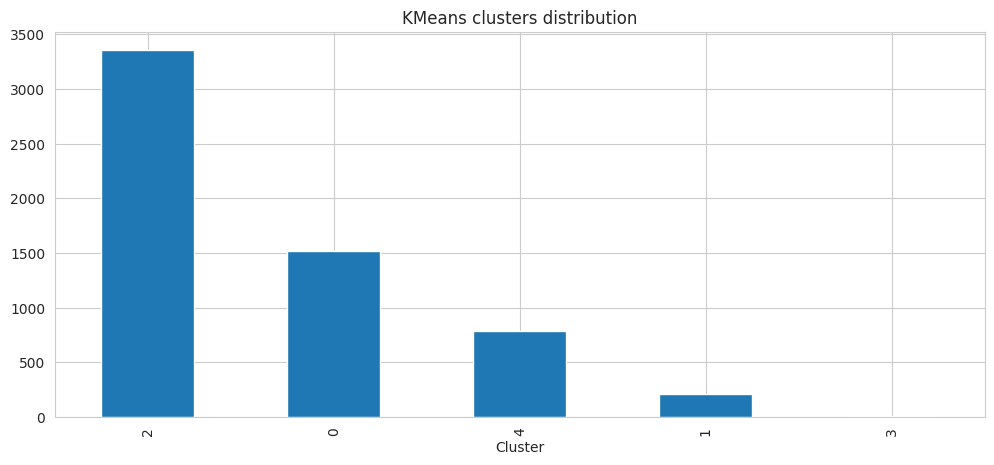

In [43]:
rfm['Cluster'].value_counts().plot(kind='bar')
plt.title('KMeans clusters distribution')
plt.show()

## 13 ML: baseline to predict high-value customers

In [44]:
# target: top 25% Monetary
rfm['HighValue'] = (rfm['Monetary'] >= rfm['Monetary'].quantile(0.75)).astype(int)
X = rfm[['Recency','Frequency','Monetary_log1p']]
y = rfm['HighValue']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
preds = model.predict(X_test)
print(classification_report(y_test,preds))
print('Confusion matrix:\n', confusion_matrix(y_test,preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       912
           1       1.00      1.00      1.00       264

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

Confusion matrix:
 [[912   0]
 [  0 264]]


### 13.1 Hyperparameter tuning (small grid)

In [46]:
param_grid = {'n_estimators':[100,200], 'max_depth':[5,10,None]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=-1)
grid.fit(X_train,y_train)
print('Best params:', grid.best_params_)

Best params: {'max_depth': 5, 'n_estimators': 100}


## 14 Time-series: simple ML forecast for monthly revenue

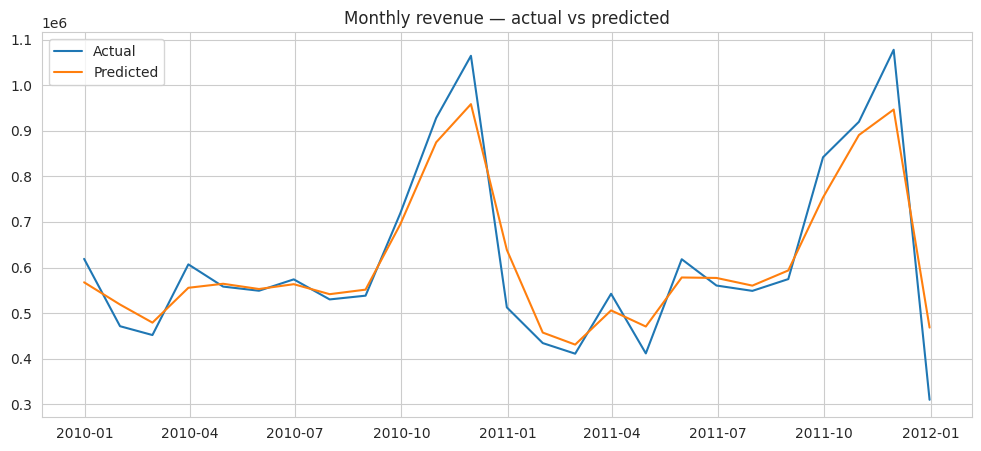

In [47]:
ts = df.resample('ME', on='InvoiceDate')['Revenue'].sum().reset_index()
ts['t'] = np.arange(len(ts))
X_ts = ts[['t']]
y_ts = ts['Revenue']
from sklearn.ensemble import RandomForestRegressor
model_reg = RandomForestRegressor(random_state=42)
model_reg.fit(X_ts, y_ts)
pred_ts = model_reg.predict(X_ts)
plt.plot(ts['InvoiceDate'], y_ts, label='Actual')
plt.plot(ts['InvoiceDate'], pred_ts, label='Predicted')
plt.title('Monthly revenue — actual vs predicted')
plt.legend(); plt.show()

## 15 Save key outputs

In [48]:
rfm.reset_index().to_csv('rfm_table.csv', index=False)
cust.to_csv('customer_table.csv', index=False)
print('Saved rfm_table.csv and customer_table.csv')

Saved rfm_table.csv and customer_table.csv


## 16 Conclusions
- I performed deep cleaning and prepared both raw and cleaned revenue columns.
- I examined concentration and cohorts; top customers drive a large share of revenue.
- I built RFM with cleaned Monetary (log1p) and an 11-tier segment mapping.
- I trained a simple ML baseline to identify high-value customers; tuning improved results.